<a href="https://colab.research.google.com/github/RaRahRasputin/Predicting-Insurance-Charges/blob/main/Insurance_charges_SDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [ ]:
# loading the dataset
df = pd.read_csv("/content/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Target variable: charges

In [ ]:
# color palette
BLUE   = "#4C78A8"
CORAL  = "#E45C3A"
TEAL   = "#3CAEA3"
AMBER  = "#F0A500"
SLATE  = "#8898AA"
BG     = "#F8F7F4"
DARK   = "#2C2C2C"
SMOKER_COLORS = {"yes": CORAL, "no": BLUE}

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "axes.edgecolor": "#CCCCCC", "axes.labelcolor": DARK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": DARK,
    "xtick.color": SLATE, "ytick.color": SLATE, "text.color": DARK,
    "grid.color": "#E5E5E5", "grid.linestyle": "--", "grid.linewidth": 0.6,
    "font.family": "sans-serif", "legend.frameon": False,
})

In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


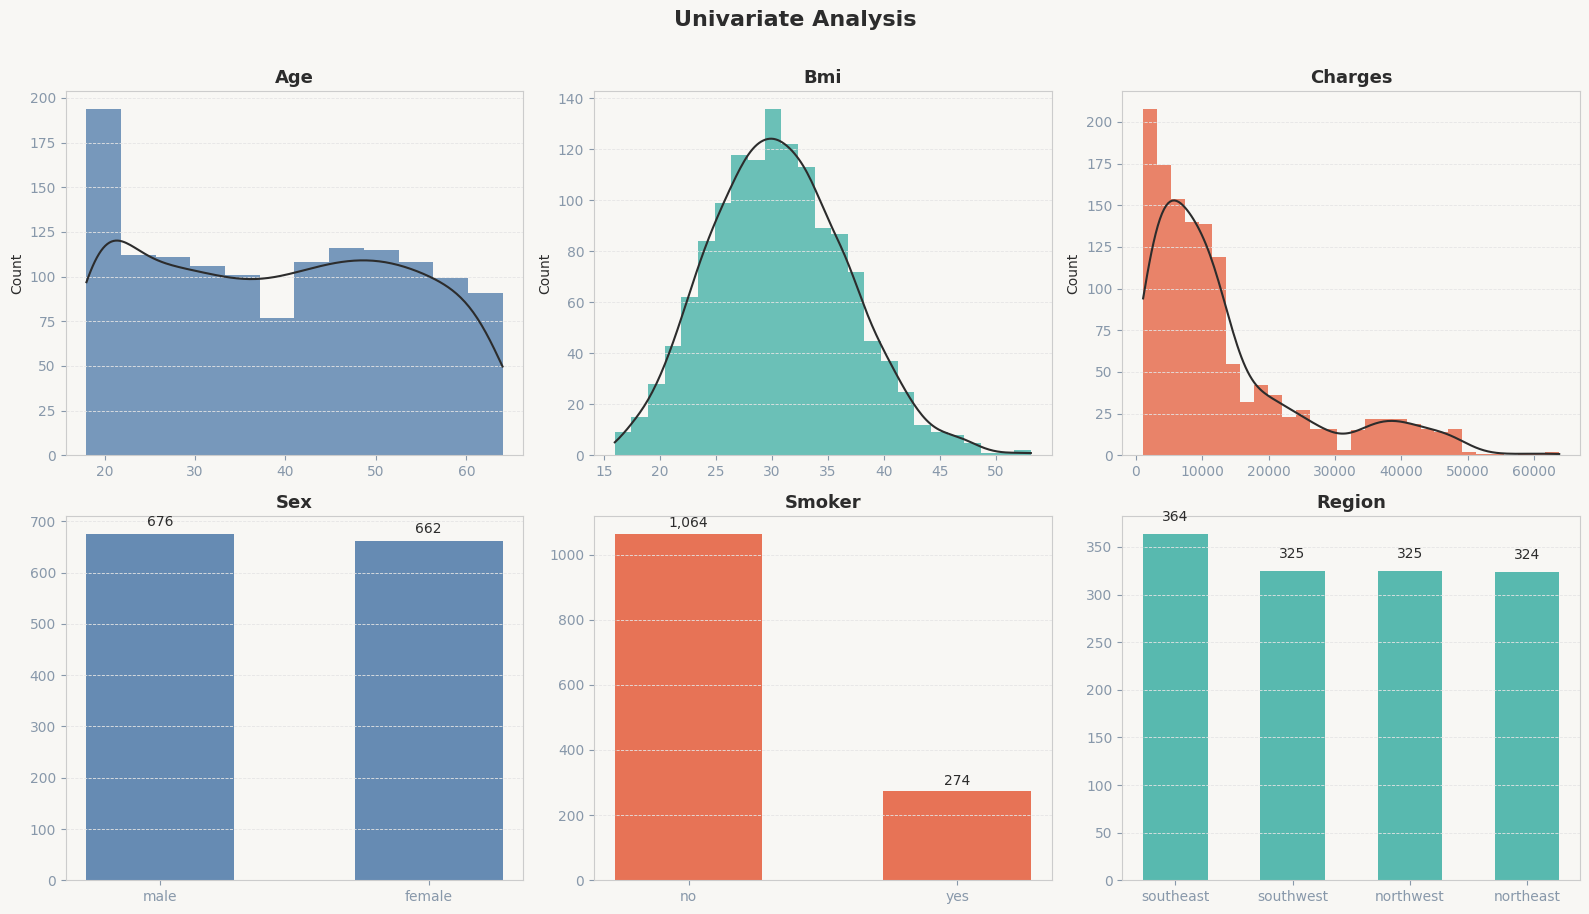

In [ ]:
#univariate
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Univariate Analysis", fontsize=16, fontweight="bold", color=DARK, y=1.01)

for ax, col, color in zip(axes[0], ["age", "bmi", "charges"], [BLUE, TEAL, CORAL]):
    sns.histplot(df[col], kde=True, ax=ax, color=color, alpha=0.75, linewidth=0)
    ax.lines[0].set_color(DARK)
    ax.set_title(col.capitalize())
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="y")

for ax, col, color in zip(axes[1], ["sex", "smoker", "region"], [BLUE, CORAL, TEAL]):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=color, alpha=0.85, width=0.55)
    ax.set_title(col.capitalize())
    ax.set_xlabel("")
    ax.grid(axis="y")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f"{int(bar.get_height()):,}", ha="center", va="bottom",
                fontsize=10, color=DARK)

plt.tight_layout()
plt.savefig("1_univariate.png", dpi=150, bbox_inches="tight")
plt.show()


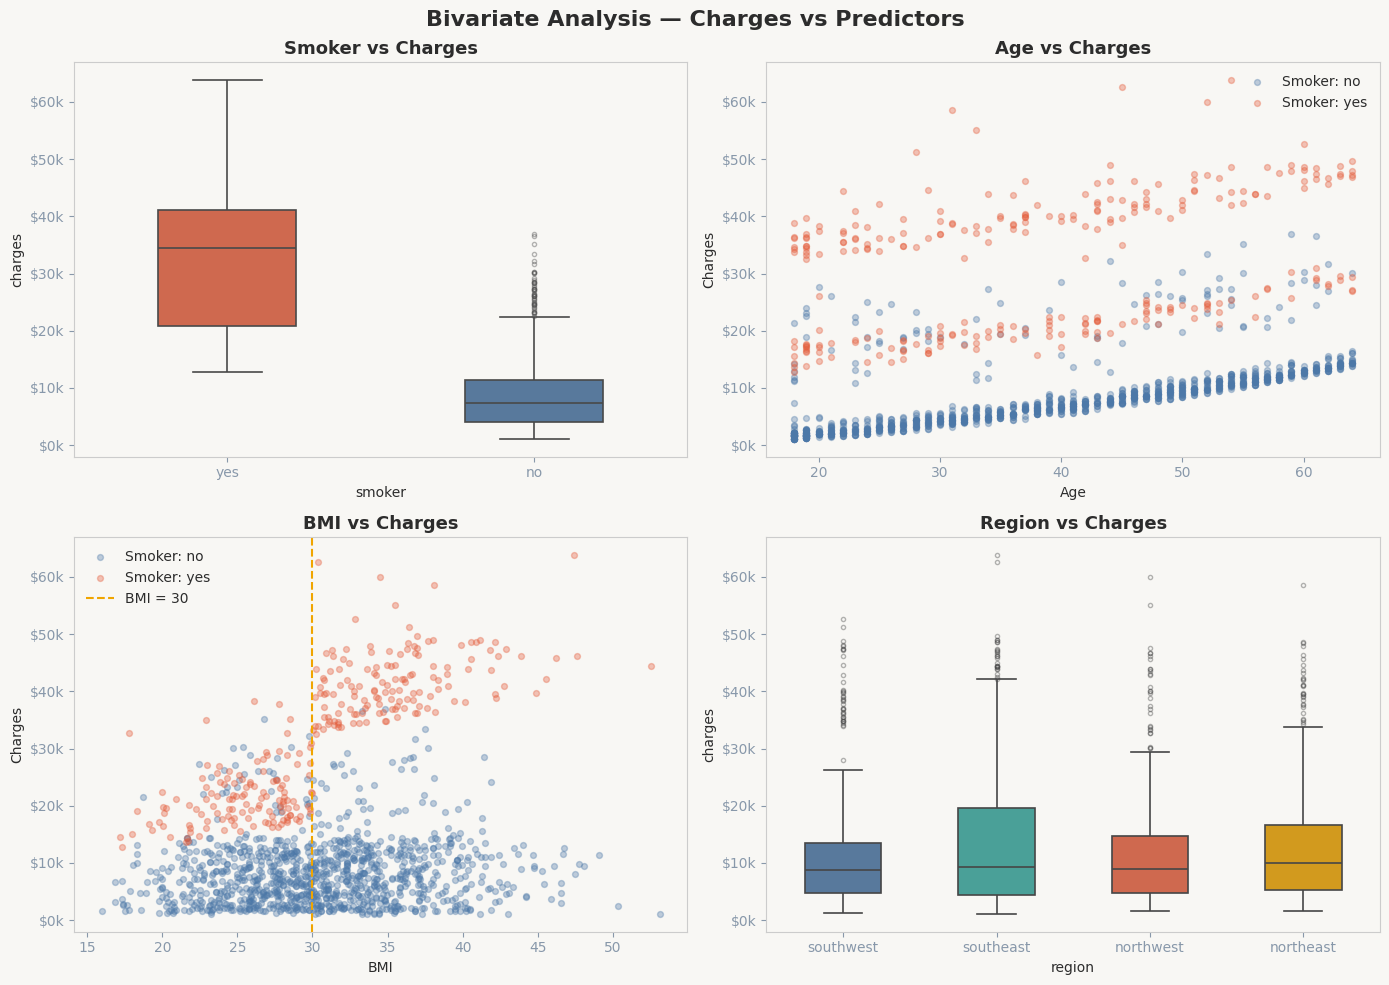

In [ ]:
#bivariate
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Bivariate Analysis — Charges vs Predictors", fontsize=16,
             fontweight="bold", color=DARK)

sns.boxplot(x="smoker", y="charges", hue = "smoker", data=df, ax=axes[0, 0],
            palette=SMOKER_COLORS, width=0.45, linewidth=1.2,
            flierprops=dict(marker="o", markersize=3, alpha=0.4, color=SLATE))
axes[0, 0].set_title("Smoker vs Charges")
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

for s, grp in df.groupby("smoker"):
    axes[0, 1].scatter(grp["age"], grp["charges"], alpha=0.35, s=18,
                       color=SMOKER_COLORS[s], label=f"Smoker: {s}")
axes[0, 1].set_title("Age vs Charges")
axes[0, 1].set_xlabel("Age"); axes[0, 1].set_ylabel("Charges")
axes[0, 1].legend(title="")
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

for s, grp in df.groupby("smoker"):
    axes[1, 0].scatter(grp["bmi"], grp["charges"], alpha=0.35, s=18,
                       color=SMOKER_COLORS[s], label=f"Smoker: {s}")
axes[1, 0].axvline(30, color=AMBER, linewidth=1.5, linestyle="--", label="BMI = 30")
axes[1, 0].set_title("BMI vs Charges")
axes[1, 0].set_xlabel("BMI"); axes[1, 0].set_ylabel("Charges")
axes[1, 0].legend(title="")
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

sns.boxplot(x="region", y="charges", hue = "region", data=df, ax=axes[1, 1],
            palette=[BLUE, TEAL, CORAL, AMBER], width=0.5, linewidth=1.2,
            flierprops=dict(marker="o", markersize=3, alpha=0.4, color=SLATE))
axes[1, 1].set_title("Region vs Charges")
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

plt.tight_layout()
plt.savefig("2_bivariate.png", dpi=150, bbox_inches="tight")
plt.show()

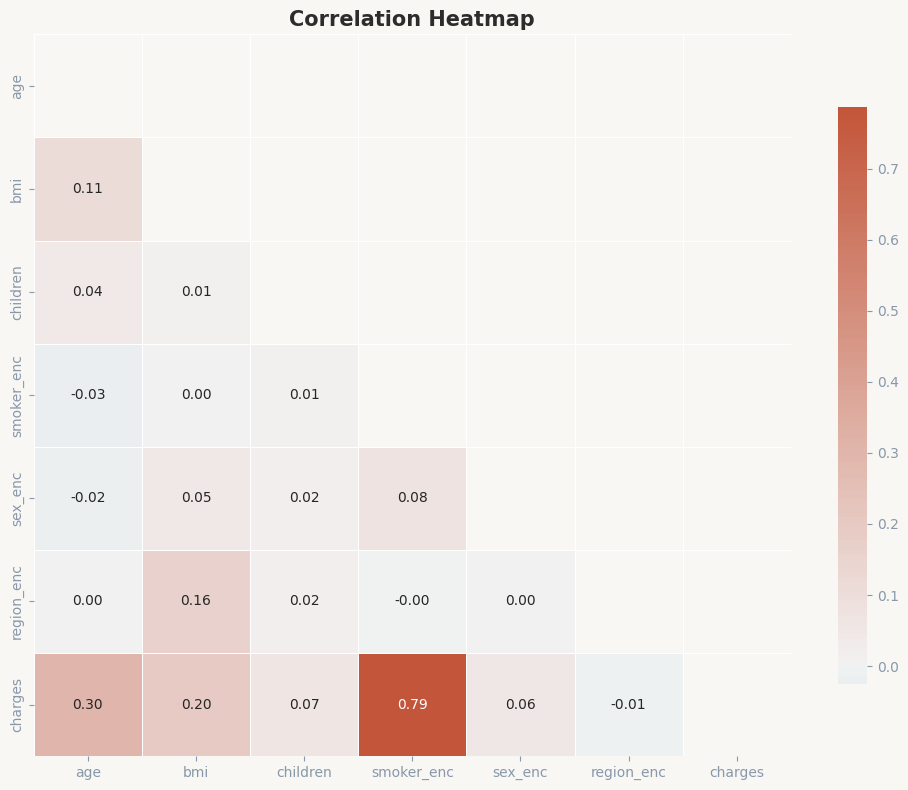

In [ ]:
# correlation heatmap
#smoker, sex, region encoded here only — just for the heatmap visualisation.
# Models use pd.get_dummies() separately, not these columns.
df_heatmap = df.copy()
df_heatmap["smoker_enc"] = (df_heatmap["smoker"] == "yes").astype(int)
df_heatmap["sex_enc"]    = (df_heatmap["sex"] == "male").astype(int)
df_heatmap["region_enc"] = df_heatmap["region"].astype("category").cat.codes

corr_cols = ["age", "bmi", "children", "smoker_enc", "sex_enc", "region_enc", "charges"]
corr = df_heatmap[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=cmap,
            center=0, linewidths=0.5, linecolor="white",
            ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("3_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

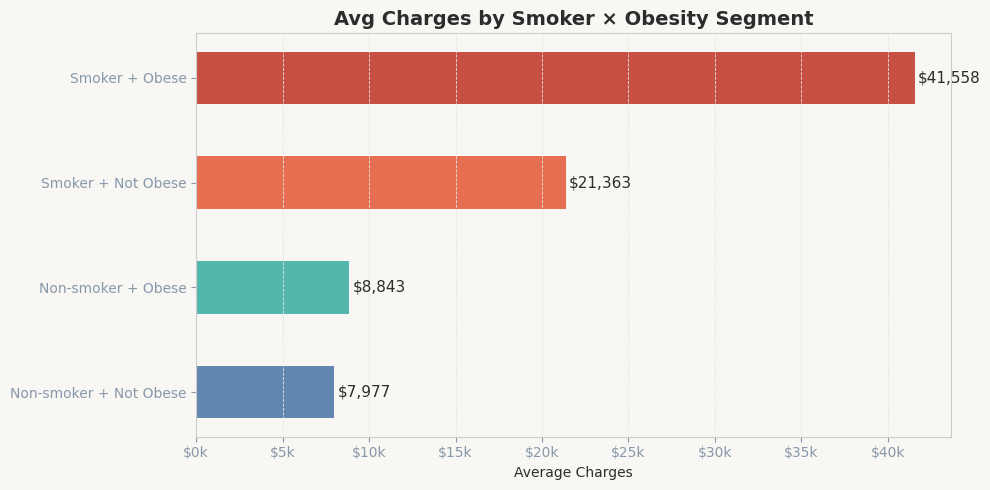

In [ ]:
# smoker vs high bmi (segmentation)
# obese flag created here for EDA visualisation

df_seg = df.copy()
df_seg["obese"]   = (df_seg["bmi"] >= 30).astype(int)
df_seg["segment"] = (df_seg["smoker"].map({"yes": "Smoker", "no": "Non-smoker"}) +
                     df_seg["obese"].map({1: " + Obese", 0: " + Not Obese"}))
seg_avg = df_seg.groupby("segment")["charges"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(seg_avg.index, seg_avg.values,
               color=[BLUE, TEAL, CORAL, "#C0392B"], alpha=0.88, height=0.5)
for bar in bars:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f"${bar.get_width():,.0f}", va="center", fontsize=11, color=DARK)
ax.set_title("Avg Charges by Smoker × Obesity Segment", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_xlabel("Average Charges")
ax.grid(axis="x")
plt.tight_layout()
plt.savefig("4_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()


Outliers: 139 rows
smoker
yes    136
no       3
Name: count, dtype: int64


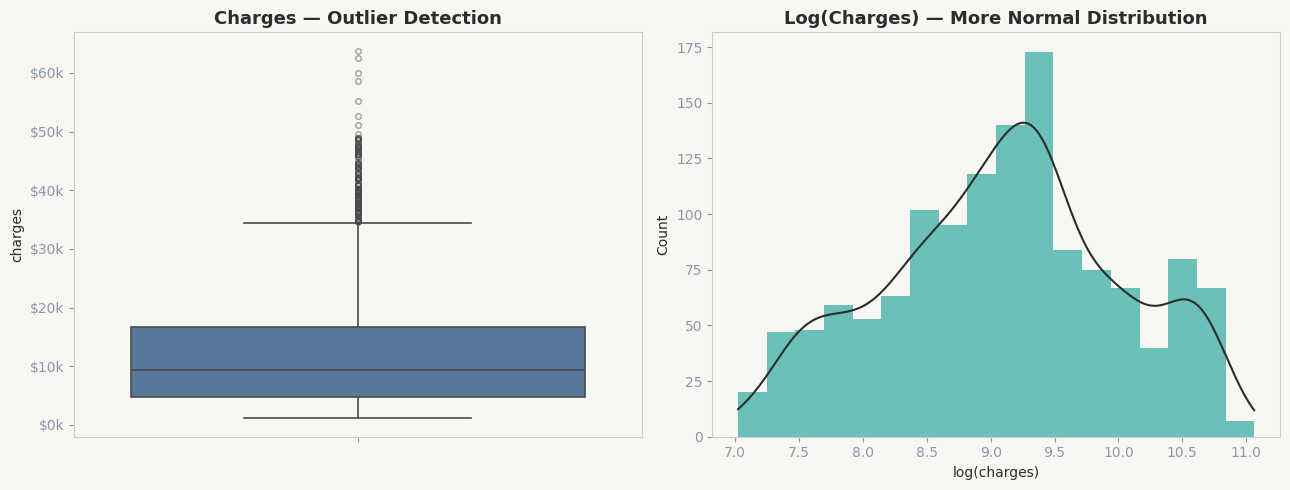

In [ ]:
# outliers + log scaling charges
Q1  = df["charges"].quantile(0.25)
Q3  = df["charges"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[df["charges"] > Q3 + 1.5 * IQR]
print(f"\nOutliers: {len(outliers)} rows")
print(outliers["smoker"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(y="charges", data=df, ax=axes[0], color=BLUE, linewidth=1.2,
            flierprops=dict(marker="o", markersize=4, alpha=0.5, color=CORAL))
axes[0].set_title("Charges — Outlier Detection")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

sns.histplot(np.log(df["charges"]), kde=True, ax=axes[1],
             color=TEAL, alpha=0.75, linewidth=0)
axes[1].lines[0].set_color(DARK)
axes[1].set_title("Log(Charges) — More Normal Distribution")
axes[1].set_xlabel("log(charges)")

plt.tight_layout()
plt.savefig("5_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:
# get_dummies handles sex, region, smoker properly for regression
df_model = pd.get_dummies(
    df[["age", "sex", "bmi", "children", "smoker", "region", "charges"]],
    columns=["sex", "region", "smoker"],
    drop_first=True
)
# smoker_yes=1/0 column is now created by get_dummies
df_model.rename(columns={"smoker_yes": "smoker_num"}, errors="ignore")

X_all = df_model.drop(columns=["charges"])
y     = df_model["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

def evaluate(name, y_true, y_pred, n_features):
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    r2     = r2_score(y_true, y_pred)
    n      = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    print(f"\n{'─'*45}\n  {name}\n{'─'*45}")
    print(f"  RMSE   : ${rmse:,.2f}")
    print(f"  R²     : {r2:.4f}")
    print(f"  Adj R² : {adj_r2:.4f}")
    return {"Model": name, "RMSE": round(rmse, 2),
            "R²": round(r2, 4), "Adj R²": round(adj_r2, 4)}

results = []

In [ ]:
# -------------------- model 1 ----------------------
# uses every column from above as is
m1 = LinearRegression().fit(X_train, y_train)
y_pred_m1 = m1.predict(X_test)
results.append(evaluate("Full Model", y_test, y_pred_m1, X_train.shape[1]))


─────────────────────────────────────────────
  Full Model
─────────────────────────────────────────────
  RMSE   : $5,796.28
  R²     : 0.7836
  Adj R² : 0.7769


In [ ]:
# ----------------- model 2 -----------------------
# Data driven model
# Key Predictors: age, bmi + obese, smoker, children

smoker_col  = [c for c in X_train.columns if "smoker" in c][0]   # smoker_yes or smoker_no
domain_cols = ["age", "bmi", "children", smoker_col]

X_dom_train = X_train[domain_cols].copy()
X_dom_test  = X_test[domain_cols].copy()

# obese flag (domain knowledge: BMI ≥ 30 is a clinically meaningful threshold)
X_dom_train["obese"] = (df.loc[X_dom_train.index, "bmi"] >= 30).astype(int)
X_dom_test["obese"]  = (df.loc[X_dom_test.index,  "bmi"] >= 30).astype(int)

m2 = LinearRegression().fit(X_dom_train, y_train)
y_pred_m2 = m2.predict(X_dom_test)
results.append(evaluate("Domain-Driven Model", y_test, y_pred_m2, X_dom_train.shape[1]))


─────────────────────────────────────────────
  Domain-Driven Model
─────────────────────────────────────────────
  RMSE   : $5,831.92
  R²     : 0.7809
  Adj R² : 0.7767


In [ ]:
# ------------- model 3 -----------------------
#   1. Target is log(charges) to fix right skew — back-transformed after prediction
#   2. smoker_obese new interaction term

y_log       = np.log(y)                                # log-transform target
y_log_train = y_log.loc[y_train.index]
y_log_test  = y_log.loc[y_test.index]

X_tr_train = X_dom_train.copy()
X_tr_test  = X_dom_test.copy()

# Interaction term: smoker & obese (only meaningful together, as EDA showed)
X_tr_train["smoker_obese"] = X_tr_train[smoker_col] * X_tr_train["obese"]
X_tr_test["smoker_obese"]  = X_tr_test[smoker_col]  * X_tr_test["obese"]

m3 = LinearRegression().fit(X_tr_train, y_log_train)
y_log_pred = m3.predict(X_tr_test)
y_pred_m3  = np.exp(y_log_pred)      # back-transform to original $ scale for comparison
results.append(evaluate("Transformed Model", y_test, y_pred_m3, X_tr_train.shape[1]))



─────────────────────────────────────────────
  Transformed Model
─────────────────────────────────────────────
  RMSE   : $7,485.68
  R²     : 0.6391
  Adj R² : 0.6308



═══════════════════════════════════════════════════════
  Model Comparison Summary
═══════════════════════════════════════════════════════
              Model    RMSE     R²  Adj R²
         Full Model 5796.28 0.7836  0.7769
Domain-Driven Model 5831.92 0.7809  0.7767
  Transformed Model 7485.68 0.6391  0.6308


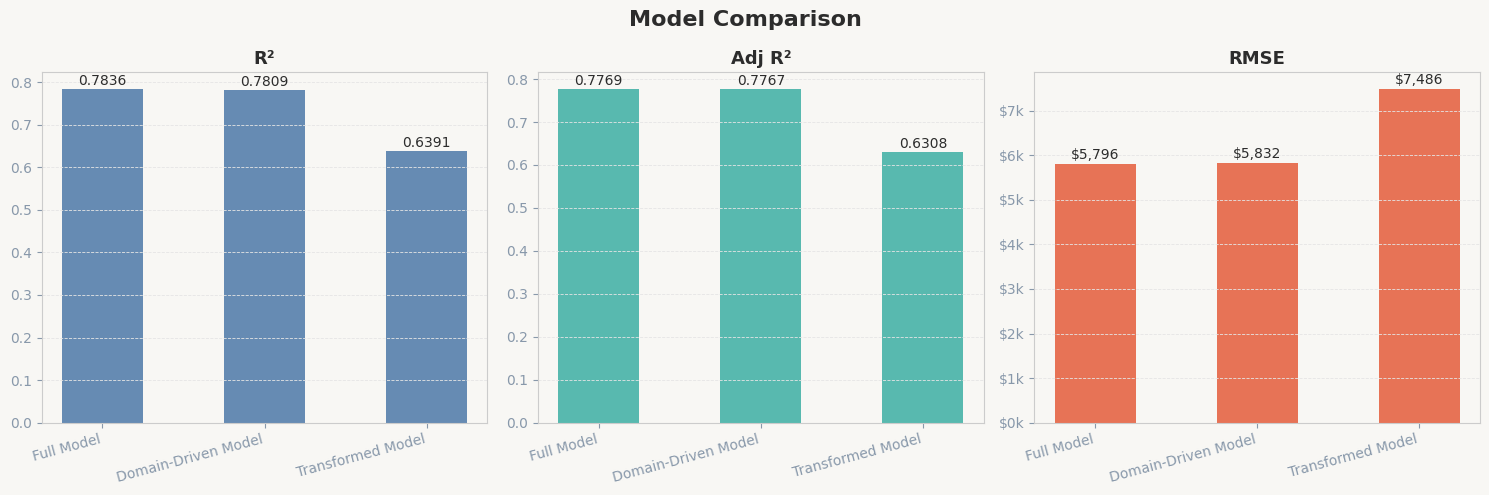

In [ ]:
# model comparison
res_df = pd.DataFrame(results)
print(f"\n{'═'*55}\n  Model Comparison Summary\n{'═'*55}")
print(res_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Comparison", fontsize=16, fontweight="bold", color=DARK)

for ax, (metric, color) in zip(axes, [("R²", BLUE), ("Adj R²", TEAL), ("RMSE", CORAL)]):
    ax.set_xticks(range(len(res_df["Model"])))
    bars = ax.bar(res_df["Model"], res_df[metric], color=color, alpha=0.85, width=0.5)
    ax.set_title(metric)
    ax.set_xticklabels(res_df["Model"], rotation=15, ha="right", fontsize=10)
    for bar in bars:
        val = bar.get_height()
        label = f"${val:,.0f}" if metric == "RMSE" else f"{val:.4f}"
        ax.text(bar.get_x() + bar.get_width()/2,
                val + (50 if metric == "RMSE" else 0.002),
                label, ha="center", va="bottom", fontsize=10, color=DARK)
    ax.grid(axis="y")
    if metric == "RMSE":
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

plt.tight_layout()
plt.savefig("6_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

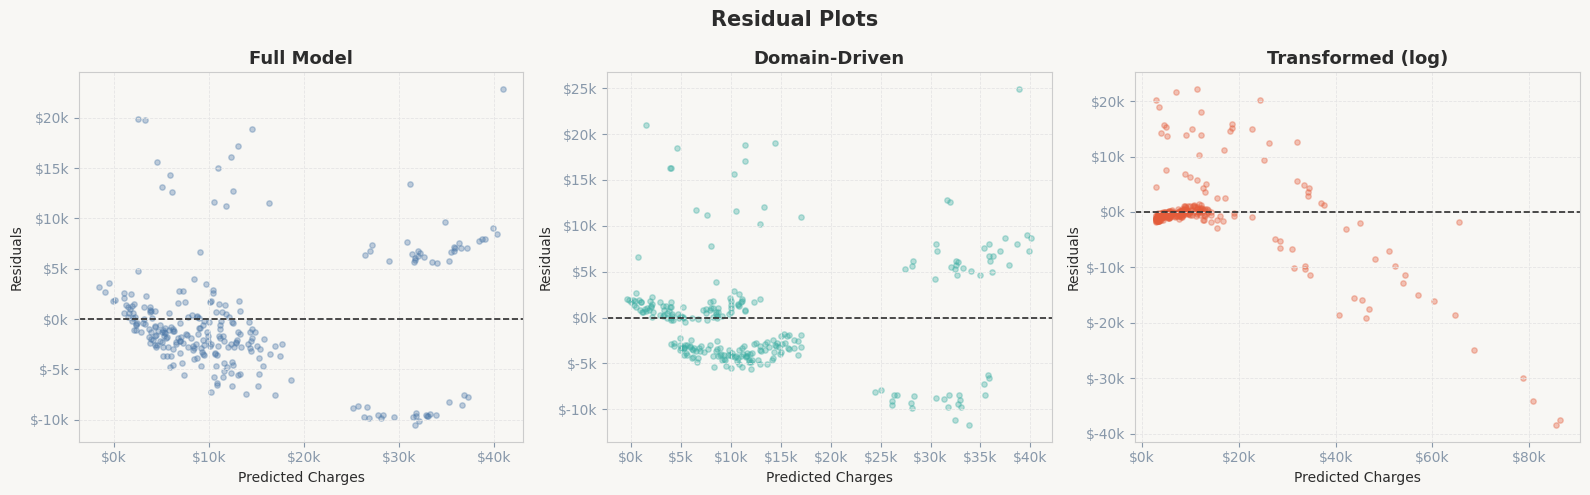

In [ ]:
#residual e
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Residual Plots", fontsize=15,
             fontweight="bold", color=DARK)

for ax, (name, y_pred, color) in zip(axes, [
    ("Full Model",        y_pred_m1, BLUE),
    ("Domain-Driven",     y_pred_m2, TEAL),
    ("Transformed (log)", y_pred_m3, CORAL),
]):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.35, s=15, color=color)
    ax.axhline(0, color=DARK, linewidth=1.2, linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("Predicted Charges")
    ax.set_ylabel("Residuals")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
    ax.grid(True)

plt.tight_layout()
plt.savefig("7_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

In [112]:
%cd Predicting-Insurance-Charges

/content/Predicting-Insurance-Charges/Predicting-Insurance-Charges


In [ ]:
!git add .

hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> Predicting-Insurance-Charges
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached Predicting-Insurance-Charges
hint: 
hint: See "git help submodule" for more information.


In [ ]:
!git status

On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Insurance_charges_SDA.ipynb
	Predicting-Insurance-Charges/
	README.md

nothing added to commit but untracked files present (use "git add" to track)


In [111]:
!ls

Insurance_charges_SDA.ipynb  Predicting-Insurance-Charges  README.md


In [ ]:
!git commit -m "Added part 1-- rough."

[main 71907f2] Added part 1-- rough.
 1 file changed, 1 insertion(+)
 create mode 160000 Predicting-Insurance-Charges


In [ ]:
!git push origin main

error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/RaRahRasputin/Predicting-Insurance-Charges.git'


In [ ]:
!git config --global user.email "raahatpathak123@gmail.com"
!git config --global user.name "RaRahRasputin"